# Thesis Evaluation Notebook

Loads `.pkl` result files and produces all thesis plots.

**Only configure Cell 2** --> change `RESULTS_DIR`, `MAX_CALLS`, `VARIANTS`, DIMENSIONS` there.

In [1]:
import os, sys, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.evaluate import postprocessing_interpolation_rewards, f_max_new

In [2]:
#RESULTS_DIR = '../experiments/thesis_experiments/results_quick'
RESULTS_DIR = '../experiments/thesis_experiments/results_200426_rep_Ab1'  # full experiment

#FIGURES_DIR = '../experiments/thesis_experiments/figures_quick'
FIGURES_DIR = '../experiments/thesis_experiments/figures'  # full experiment

MAX_CALLS = 300    # 10 for quick, 300 for full

#VARIANTS = [
 #   ('gibo_baseline_quick',   'GIBO Baseline'),
 #   ('gibo_prob_wolfe_quick', 'Prob Wolfe'),
 #   ('gibo_det_ei_quick',     'Det EI'),
#]
# For full experiment:
VARIANTS = [
     ('gibo_baseline',   'GIBO Baseline'),
     ('gibo_prob_wolfe', 'Prob Wolfe'),
     ('gibo_det_ei',     'Det EI'),
]

DIMENSIONS = [4, 8, 12, 16, 20, 24, 28, 32, 36]

# Create figures directory
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f'Figures will be saved to: {FIGURES_DIR}')

Figures will be saved to: ../experiments/thesis_experiments/figures


## Block 1: Load pkl Files

In [3]:
def load_variant(results_dir, name, dimensions):
    data = {k: {} for k in [
        'calls', 'best_so_far', 'f_max',
        'inner_loop_samples', 'step_sizes', 'gradient_norms',
        'p_wolfe_values', 'wolfe_satisfied', 'armijo_ok', 'curvature_ok',
        'f_values',   # parameter positions per iteratio
    ]}
    for dim in dimensions:
        dim_dir = os.path.join(results_dir, name, f'dim_{dim}')
        if not os.path.isdir(dim_dir):
            continue
        pkl_files = sorted(f for f in os.listdir(dim_dir) if f.endswith('.pkl'))
        if not pkl_files:
            continue
        calls_d, bsf_d, fmax_d = [], [], []
        ils_d, ss_d, gn_d = [], [], []
        pw_d, ws_d, arm_d, cur_d = [], [], [], []
        fv_d = []
        for fname in pkl_files:
            with open(os.path.join(dim_dir, fname), 'rb') as fh:
                r = pickle.load(fh)
            fmv    = float(r['f_max'])
            regret = r['regret_per_eval']
            calls  = r['calls_at_iteration']
            bsf    = [fmv - rg for rg in regret]
            calls_d.append(calls)
            bsf_d.append([0.0] + bsf)
            fmax_d.append(fmv)
            ils_d.append(r.get('inner_loop_samples', []))
            ss_d.append(r.get('step_sizes', []))
            gn_d.append(r.get('gradient_norms', []))
            pw_d.append(r.get('p_wolfe_values', []))
            ws_d.append(r.get('wolfe_satisfied', []))
            arm_d.append(r.get('armijo_ok', []))
            cur_d.append(r.get('curvature_ok', []))
            fv_d.append(r.get('f_values', []))
        data['calls'][dim]              = calls_d
        data['best_so_far'][dim]        = bsf_d
        data['f_max'][dim]              = fmax_d
        data['inner_loop_samples'][dim] = ils_d
        data['step_sizes'][dim]         = ss_d
        data['gradient_norms'][dim]     = gn_d
        data['p_wolfe_values'][dim]     = pw_d
        data['wolfe_satisfied'][dim]    = ws_d
        data['armijo_ok'][dim]          = arm_d
        data['curvature_ok'][dim]       = cur_d
        data['f_values'][dim]           = fv_d
        print(f'  dim={dim}: {len(pkl_files)} runs')
    return data


all_data = {}
for vname, vlabel in VARIANTS:
    print(f'Loading {vlabel} ({vname}) ...')
    all_data[vname] = load_variant(RESULTS_DIR, vname, DIMENSIONS)

available_dims = [
    d for d in DIMENSIONS
    if all(d in all_data[vn]['calls'] for vn, _ in VARIANTS)
]
print(f'\nAvailable dims: {available_dims}')

Loading GIBO Baseline (gibo_baseline) ...
  dim=4: 40 runs
  dim=8: 40 runs
  dim=12: 40 runs
  dim=16: 40 runs
  dim=20: 40 runs
  dim=24: 40 runs
  dim=28: 40 runs
  dim=32: 40 runs
  dim=36: 40 runs
Loading Prob Wolfe (gibo_prob_wolfe) ...
  dim=4: 40 runs
  dim=8: 40 runs
  dim=12: 40 runs
  dim=16: 40 runs
  dim=20: 40 runs
  dim=24: 40 runs
  dim=28: 40 runs
  dim=32: 40 runs
  dim=36: 40 runs
Loading Det EI (gibo_det_ei) ...
  dim=4: 40 runs
  dim=8: 40 runs
  dim=12: 40 runs
  dim=16: 40 runs
  dim=20: 40 runs
  dim=24: 40 runs
  dim=28: 40 runs
  dim=32: 40 runs
  dim=36: 40 runs

Available dims: [4, 8, 12, 16, 20, 24, 28, 32, 36]


## Block 2: Interpolate to Common Call Grid

In [4]:
def interpolate_rewards(rewards_dict, calls_dict, max_calls):
    """
    Robust replacement for postprocessing_interpolation_rewards.
    Handles cases where last call < max_calls - 1 (avoids IndexError).

    rewards_dict : {dim: [[r0, r1, ...], ...]}  len(rewards) = len(calls) + 1
    calls_dict   : {dim: [[c0, c1, ..], ...]}
    Returns      : Tensor (n_dims, n_runs, max_calls)
    """
    dimensions = list(rewards_dict.keys())
    n_runs = len(rewards_dict[dimensions[0]])
    out = torch.zeros(len(dimensions), n_runs, max_calls)
    for idx_d, dim in enumerate(dimensions):
        for idx_r in range(n_runs):
            rewards = rewards_dict[dim][idx_r]
            calls   = calls_dict[dim][idx_r]
            ir = 0
            for call in range(max_calls):
                if ir < len(calls) and call == calls[ir]:
                    ir += 1
                out[idx_d, idx_r, call] = rewards[ir]
    return out


interpolated = {}
for vname, vlabel in VARIANTS:
    d = all_data[vname]
    rewards_dict = {dim: d['best_so_far'][dim] for dim in available_dims}
    calls_dict   = {dim: d['calls'][dim]       for dim in available_dims}
    interpolated[vname] = interpolate_rewards(rewards_dict, calls_dict, MAX_CALLS)
    print(f'{vlabel}: {interpolated[vname].shape}')

first_vname     = VARIANTS[0][0]
f_max_dict      = {dim: all_data[first_vname]['f_max'][dim] for dim in available_dims}
f_max_corrected = f_max_new(f_max_dict, list(interpolated.values()))

names   = [label for _, label in VARIANTS]
tensors = [interpolated[vname] for vname, _ in VARIANTS]

GIBO Baseline: torch.Size([9, 40, 300])
Prob Wolfe: torch.Size([9, 40, 300])
Det EI: torch.Size([9, 40, 300])


## Block 3: Regret vs Evaluations

Saved: ../experiments/thesis_experiments/figures\regret_vs_evals.pdf


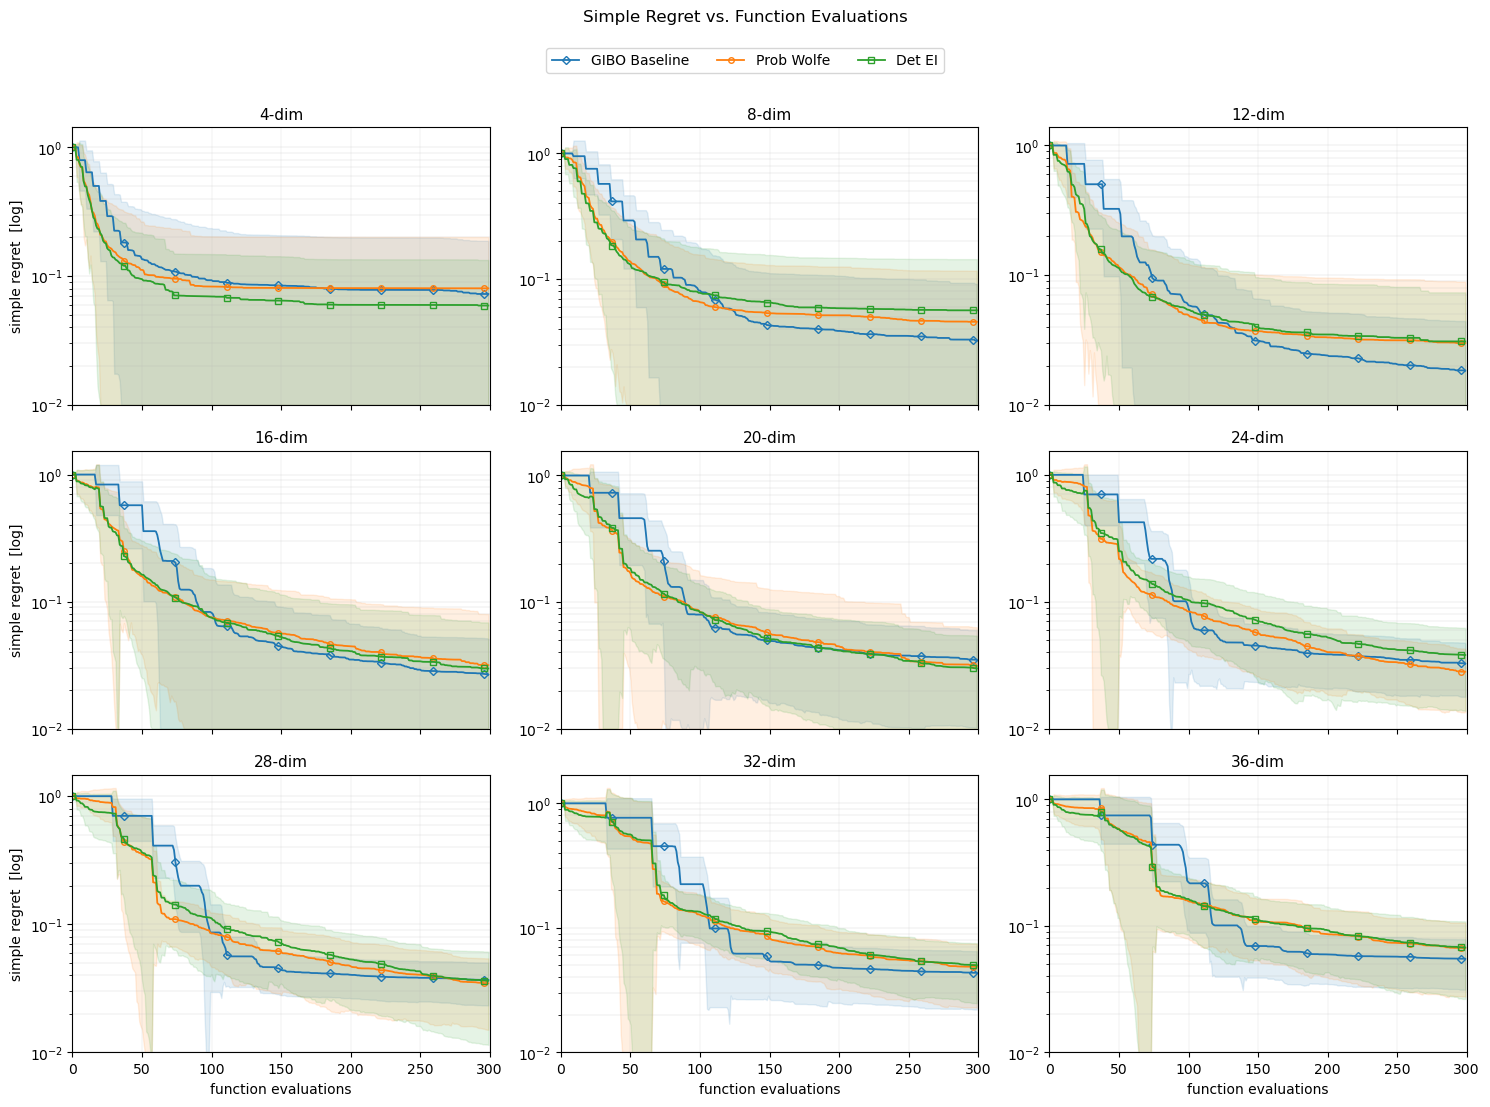


Final simple regret at 300 evaluations  (mean ± std  |  median)
  Dim                   GIBO Baseline                      Prob Wolfe                          Det EI
-------------------------------------------------------------------------------------------------------
    4    0.0716 ± 0.1160  med 0.0324    0.0789 ± 0.1216  med 0.0304    0.0576 ± 0.0754  med 0.0280  
    8    0.0302 ± 0.0603  med 0.0090    0.0424 ± 0.0726  med 0.0066    0.0535 ± 0.0894  med 0.0072  
   12    0.0175 ± 0.0262  med 0.0104    0.0267 ± 0.0603  med 0.0060    0.0279 ± 0.0443  med 0.0075  
   16    0.0265 ± 0.0243  med 0.0189    0.0312 ± 0.0484  med 0.0133    0.0290 ± 0.0393  med 0.0158  
   20    0.0351 ± 0.0249  med 0.0259    0.0311 ± 0.0320  med 0.0179    0.0296 ± 0.0246  med 0.0229  
   24    0.0325 ± 0.0146  med 0.0262    0.0281 ± 0.0146  med 0.0216    0.0380 ± 0.0242  med 0.0340  
   28    0.0367 ± 0.0135  med 0.0352    0.0346 ± 0.0196  med 0.0293    0.0362 ± 0.0249  med 0.0277  
   32    0.0435 ± 0.02

In [5]:
def plot_regret(f_max, rewards_list, names, available_dims, max_calls, show_std=True, path=None):
    markers = ['D', 'o', 's']
    colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']
    n      = len(available_dims)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    x = np.arange(max_calls)

    fig, axs = plt.subplots(n_rows, n_cols, sharex=True, sharey=False,
                             figsize=(5 * n_cols, 3.5 * n_rows))
    axs = np.array(axs).reshape(-1)

    for idx_d, dim in enumerate(available_dims):
        ax  = axs[idx_d]
        fmx = np.array(f_max[dim]).reshape(-1, 1)
        ax.set_title(f'{dim}-dim', fontsize=11)
        ax.set_xlim([0, max_calls])
        if idx_d >= n_cols * (n_rows - 1):
            ax.set_xlabel('function evaluations', labelpad=5)
        if idx_d % n_cols == 0:
            ax.set_ylabel('simple regret  [log]')

        for idx_o, (rew, name) in enumerate(zip(rewards_list, names)):
            rew_np = rew[idx_d].numpy()
            err    = (fmx - rew_np) / fmx
            err    = np.clip(err, 1e-2, None)
            mean   = err.mean(0)
            std    = err.std(0)
            ax.plot(x, mean, label=name,
                    marker=markers[idx_o],
                    markevery=max(1, max_calls // 8),
                    markersize=4, linewidth=1.3,
                    color=colors[idx_o], fillstyle='none')
            if show_std:
                ax.fill_between(x,
                                np.clip(mean - std, 1e-2, None),
                                mean + std,
                                alpha=0.12, color=colors[idx_o])

        ax.set_yscale('log')
        ax.set_ylim([1e-2, None])
        ax.yaxis.grid(True, which='both', linewidth=0.3, alpha=0.5)
        ax.xaxis.grid(True, linewidth=0.3, alpha=0.4)

    for idx in range(len(available_dims), n_rows * n_cols):
        axs[idx].set_visible(False)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, 1.02), ncol=len(names),
               frameon=True, fontsize=10)
    fig.suptitle('Simple Regret vs. Function Evaluations', fontsize=12, y=1.05)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


plot_regret(f_max_corrected, tensors, names, available_dims, MAX_CALLS, show_std=True,
            path=os.path.join(FIGURES_DIR, 'regret_vs_evals.pdf'))

# Numeric summary: final simple regret at budget exhaustion
w = 30
print(f'\nFinal simple regret at {MAX_CALLS} evaluations  (mean ± std  |  median)')
print(f"{'Dim':>5}  " + '  '.join(f'{n:>{w}}' for n in names))
print('-' * (7 + (w + 2) * len(names)))
for idx_d, dim in enumerate(available_dims):
    fmx = np.array(f_max_corrected[dim]).reshape(-1)
    row = f'{dim:>5}  '
    for rew in tensors:
        best = rew[idx_d].numpy()[:, -1]
        err  = np.clip((fmx - best) / fmx, 0, None)
        row += f'  {np.mean(err):.4f} ± {np.std(err):.4f}  med {np.median(err):.4f}  '
    print(row)

## Block 4: Final Regret Boxplots over Dimensions

Saved: ../experiments/thesis_experiments/figures\boxplots_final_regret.pdf


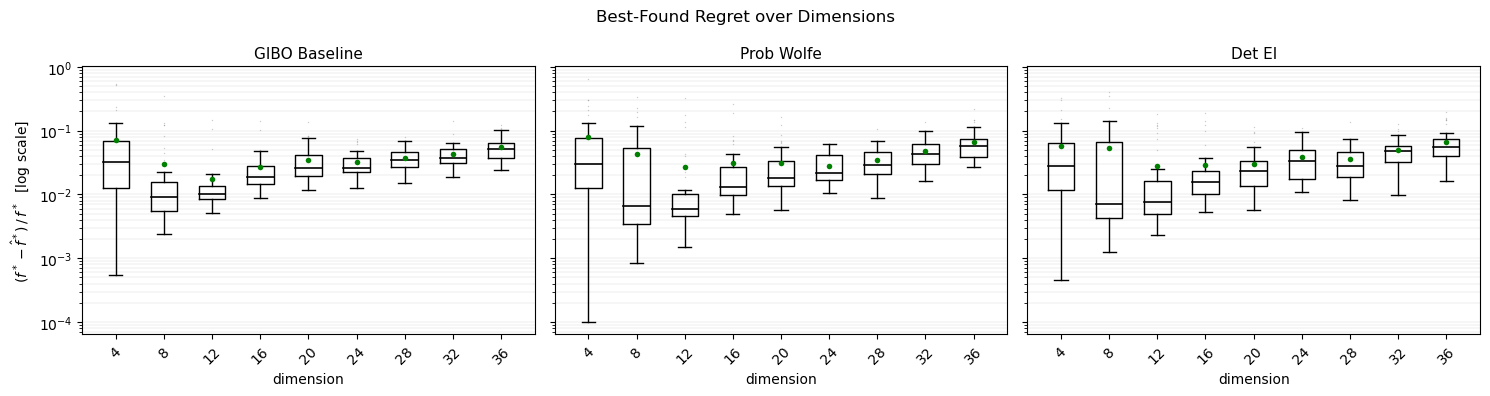

In [6]:
def plot_boxplots(f_max, rewards_list, names, available_dims, path=None):
    n_opt  = len(rewards_list)
    fig, axs = plt.subplots(1, n_opt, sharex=True, sharey=True, figsize=(5 * n_opt, 4))
    if n_opt == 1:
        axs = [axs]

    medp   = dict(linestyle='-', linewidth=1.2, color='black')
    meanp  = dict(marker='o', markerfacecolor='green', markersize=4, markeredgecolor='none')
    flierp = dict(marker='.', markerfacecolor='gray', markersize=2, alpha=0.4,
                  markeredgecolor='none')

    for idx, (rew, name) in enumerate(zip(rewards_list, names)):
        fve = []
        for idx_d, dim in enumerate(available_dims):
            fmx  = torch.tensor(f_max[dim])
            maxr = rew[idx_d].max(-1).values
            vals = ((fmx - maxr) / fmx).numpy()
            vals = np.clip(vals, 1e-4, None)   # avoid log(0)
            fve.append(vals)

        axs[idx].boxplot(fve, positions=available_dims, widths=2.2,
                         showfliers=True, showmeans=True,
                         meanprops=meanp, medianprops=medp,
                         flierprops=flierp)
        axs[idx].set_yscale('log')
        axs[idx].yaxis.grid(True, which='both', linewidth=0.3, alpha=0.5)
        axs[idx].set_xlabel('dimension')
        axs[idx].set_title(name, fontsize=11)
        axs[idx].set_xticks(available_dims)
        axs[idx].tick_params(axis='x', labelrotation=45)

    axs[0].set_ylabel(r'$(f^* - \hat{f}^*)\,/\,f^*$  [log scale]')
    plt.suptitle('Best-Found Regret over Dimensions', fontsize=12)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


plot_boxplots(f_max_corrected, tensors, names, available_dims,
              path=os.path.join(FIGURES_DIR, 'boxplots_final_regret.pdf'))

## Block 5: RQ1 - Inner Loop Sample Counts

Saved: ../experiments/thesis_experiments/figures\inner_loop_samples.pdf


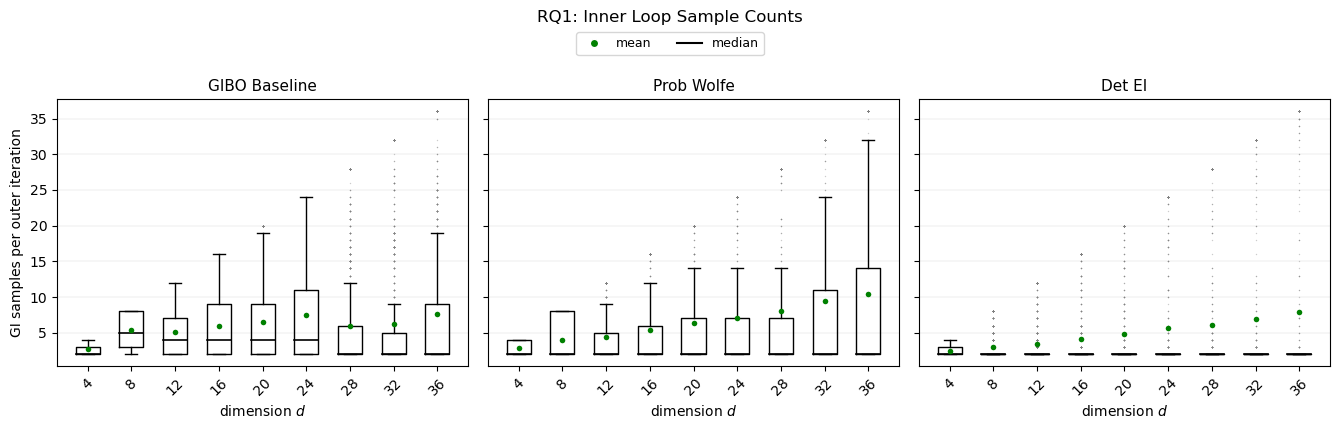


  Dim             GIBO Baseline                Prob Wolfe                    Det EI
-------------------------------------------------------------------------------------
    4     2.71 ± 0.80  med  2.0     2.88 ± 0.94  med  2.0     2.47 ± 0.82  med  2.0  
    8     5.38 ± 2.13  med  5.0     3.99 ± 2.60  med  2.0     3.07 ± 2.18  med  2.0  
   12     5.16 ± 3.37  med  4.0     4.36 ± 3.87  med  2.0     3.44 ± 3.29  med  2.0  
   16     5.96 ± 4.51  med  4.0     5.40 ± 5.51  med  2.0     4.10 ± 4.75  med  2.0  
   20     6.48 ± 5.65  med  4.0     6.34 ± 7.25  med  2.0     4.76 ± 6.19  med  2.0  
   24     7.53 ± 6.75  med  4.0     7.11 ± 8.69  med  2.0     5.71 ± 7.94  med  2.0  
   28     5.99 ± 7.08  med  2.0     8.01 ± 10.41  med  2.0     6.05 ± 9.12  med  2.0  
   32     6.19 ± 8.15  med  2.0     9.43 ± 12.41  med  2.0     6.94 ± 10.84  med  2.0  
   36     7.67 ± 9.76  med  2.0    10.42 ± 14.06  med  2.0     7.92 ± 12.59  med  2.0  


In [7]:
def plot_inner_samples(all_data, variants, available_dims, path=None):
    """Boxplot per variant (one panel each, shared y-axis).
    Shows full distribution of GI samples per outer iteration across all runs and dims.
    Numeric table printed below.
    """
    n = len(variants)
    fig, axs = plt.subplots(1, n, sharex=True, sharey=True, figsize=(4.5 * n, 4))
    if n == 1:
        axs = [axs]

    medp   = dict(linestyle='-', linewidth=1.2, color='black')
    meanp  = dict(marker='o', markerfacecolor='green', markersize=4, markeredgecolor='none')
    flierp = dict(marker='.', markerfacecolor='gray', markersize=2,
                  alpha=0.4, markeredgecolor='none')

    for idx, (vname, vlabel) in enumerate(variants):
        ax = axs[idx]
        data_per_dim = []
        for dim in available_dims:
            vals = []
            for run in all_data[vname]['inner_loop_samples'].get(dim, []):
                vals.extend([s for s in run if s is not None])
            data_per_dim.append(np.array(vals if vals else [0], dtype=float))

        ax.boxplot(data_per_dim, positions=available_dims, widths=2.2,
                   showfliers=True, showmeans=True,
                   meanprops=meanp, medianprops=medp, flierprops=flierp)
        ax.set_xlabel('dimension $d$')
        ax.set_title(vlabel, fontsize=11)
        ax.set_xticks(available_dims)
        ax.tick_params(axis='x', labelrotation=45)
        ax.yaxis.grid(True, which='both', linewidth=0.3, alpha=0.5)

    axs[0].set_ylabel('GI samples per outer iteration')
    #Single shared legend: green dot = mean, black bar = median
    from matplotlib.lines import Line2D
    legend_els = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
               markersize=6, label='mean'),
        Line2D([0], [0], color='black', lw=1.5, label='median'),
    ]
    fig.legend(handles=legend_els, loc='upper center',
               bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True, fontsize=9)
    plt.suptitle('RQ1: Inner Loop Sample Counts', fontsize=12, y=1.06)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()

    # Numeric summary table 
    w = 24
    print(f"\n{'Dim':>5}  " + '  '.join(f'{lb:>{w}}' for _, lb in variants))
    print('-' * (7 + (w + 2) * len(variants)))
    for dim in available_dims:
        row = f'{dim:>5}  '
        for vname, _ in variants:
            vals = []
            for run in all_data[vname]['inner_loop_samples'].get(dim, []):
                vals.extend([s for s in run if s is not None])
            if vals:
                a = np.array(vals)
                row += f'  {np.mean(a):5.2f} ± {np.std(a):4.2f}  med {np.median(a):4.1f}  '
            else:
                row += f'{"n/a":>{w}}  '
        print(row)


plot_inner_samples(all_data, VARIANTS, available_dims,
                   path=os.path.join(FIGURES_DIR, 'inner_loop_samples.pdf'))

## Block 6: RQ2 - Step Size Distribution

Saved: ../experiments/thesis_experiments/figures\step_sizes.pdf


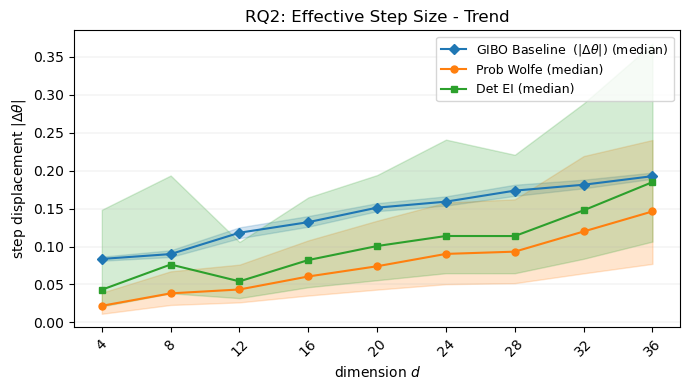

Saved: ../experiments/thesis_experiments/figures\step_sizes_boxes.pdf


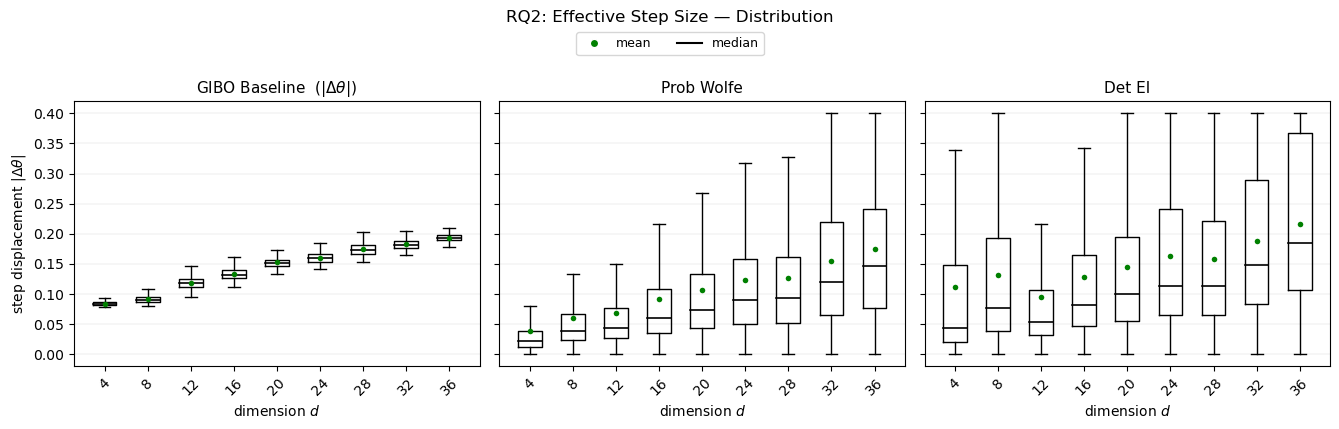


Step displacement per outer iteration  (mean ± std  |  median)
  Dim               GIBO Baseline                  Prob Wolfe                      Det EI
-------------------------------------------------------------------------------------------
    4    0.0841 ± 0.0035  med 0.0837    0.0391 ± 0.0581  med 0.0219    0.1110 ± 0.1328  med 0.0431  
    8    0.0914 ± 0.0072  med 0.0901    0.0604 ± 0.0690  med 0.0383    0.1318 ± 0.1254  med 0.0763  
   12    0.1183 ± 0.0100  med 0.1182    0.0683 ± 0.0744  med 0.0434    0.0942 ± 0.1018  med 0.0541  
   16    0.1337 ± 0.0100  med 0.1322    0.0917 ± 0.0893  med 0.0605    0.1284 ± 0.1153  med 0.0822  
   20    0.1527 ± 0.0084  med 0.1513    0.1068 ± 0.0955  med 0.0740    0.1450 ± 0.1185  med 0.1007  
   24    0.1606 ± 0.0089  med 0.1592    0.1226 ± 0.1015  med 0.0903    0.1627 ± 0.1248  med 0.1139  
   28    0.1752 ± 0.0109  med 0.1737    0.1273 ± 0.1063  med 0.0933    0.1589 ± 0.1213  med 0.1139  
   32    0.1836 ± 0.0097  med 0.1815    0.1555 

In [8]:
def _get_step_vals(all_data, vname, dim):
    """Return per-iteration step displacements for one variant and dimension.

    Baseline (normalize_gradient=True): actual ||θ_{t+1} − θ_t|| from f_values.
    Line-search variants: stored alpha* values.
    """
    if 'baseline' in vname:
        vals = []
        for fv_run in all_data[vname]['f_values'].get(dim, []):
            for t in range(len(fv_run) - 1):
                a = np.array(fv_run[t]).flatten()
                b = np.array(fv_run[t + 1]).flatten()
                vals.append(float(np.linalg.norm(b - a)))
        return vals
    else:
        vals = []
        for run in all_data[vname]['step_sizes'].get(dim, []):
            vals.extend([a for a in run if a is not None])
        return vals


def plot_step_sizes(all_data, variants, available_dims, path=None):
    """Median + IQR band --> all three variants on one axis for trend comparison."""
    colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']
    markers = ['D',       'o',       's']

    fig, ax = plt.subplots(figsize=(7, 4))
    for idx, (vname, vlabel) in enumerate(variants):
        medians, q25s, q75s = [], [], []
        for dim in available_dims:
            vals = _get_step_vals(all_data, vname, dim)
            if vals:
                a = np.array(vals, dtype=float)
                medians.append(np.median(a))
                q25s.append(np.percentile(a, 25))
                q75s.append(np.percentile(a, 75))
            else:
                medians.append(np.nan); q25s.append(np.nan); q75s.append(np.nan)

        lbl = vlabel if 'baseline' not in vname else f'{vlabel}  ($\\|\\Delta\\theta\\|$)'
        ax.plot(available_dims, medians, color=colors[idx], marker=markers[idx],
                lw=1.5, markersize=5, label=f'{lbl} (median)')
        ax.fill_between(available_dims, q25s, q75s, alpha=0.2, color=colors[idx])

    ax.set_xlabel('dimension $d$')
    ax.set_ylabel(r'step displacement $\|\Delta\theta\|$')
    ax.set_xticks(available_dims)
    ax.tick_params(axis='x', labelrotation=45)
    ax.yaxis.grid(True, linewidth=0.3, alpha=0.5)
    ax.legend(fontsize=9)
    ax.set_title('RQ2: Effective Step Size - Trend', fontsize=12)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


def plot_step_sizes_boxes(all_data, variants, available_dims, path=None):
    """Boxplot per variant (one panel each, shared y-axis) --> distribution view."""
    n = len(variants)
    fig, axs = plt.subplots(1, n, sharex=True, sharey=True, figsize=(4.5 * n, 4))
    if n == 1:
        axs = [axs]

    medp   = dict(linestyle='-', linewidth=1.2, color='black')
    meanp  = dict(marker='o', markerfacecolor='green', markersize=4, markeredgecolor='none')
    flierp = dict(marker='.', markerfacecolor='gray', markersize=2,
                  alpha=0.4, markeredgecolor='none')

    for idx, (vname, vlabel) in enumerate(variants):
        ax = axs[idx]
        data_per_dim = []
        for dim in available_dims:
            vals = _get_step_vals(all_data, vname, dim)
            data_per_dim.append(np.array(vals if vals else [0.0], dtype=float))

        ax.boxplot(data_per_dim, positions=available_dims, widths=2.2,
                   showfliers=False, showmeans=True,
                   meanprops=meanp, medianprops=medp, flierprops=flierp)
        lbl = vlabel if 'baseline' not in vname else f'{vlabel}  ($\\|\\Delta\\theta\\|$)'
        ax.set_title(lbl, fontsize=11)
        ax.set_xlabel('dimension $d$')
        ax.set_xticks(available_dims)
        ax.tick_params(axis='x', labelrotation=45)
        ax.yaxis.grid(True, linewidth=0.3, alpha=0.5)

    axs[0].set_ylabel(r'step displacement $\|\Delta\theta\|$')
    from matplotlib.lines import Line2D
    legend_els = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
               markersize=6, label='mean'),
        Line2D([0], [0], color='black', lw=1.5, label='median'),
    ]
    fig.legend(handles=legend_els, loc='upper center',
               bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True, fontsize=9)
    plt.suptitle('RQ2: Effective Step Size — Distribution', fontsize=12, y=1.06)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
    plt.show()


plot_step_sizes(all_data, VARIANTS, available_dims,
                path=os.path.join(FIGURES_DIR, 'step_sizes.pdf'))

plot_step_sizes_boxes(all_data, VARIANTS, available_dims,
                      path=os.path.join(FIGURES_DIR, 'step_sizes_boxes.pdf'))

# Numeric summary table
w = 26
print(f'\nStep displacement per outer iteration  (mean ± std  |  median)')
print(f"{'Dim':>5}  " + '  '.join(f'{lb:>{w}}' for _, lb in VARIANTS))
print('-' * (7 + (w + 2) * len(VARIANTS)))
for dim in available_dims:
    row = f'{dim:>5}  '
    for vname, _ in VARIANTS:
        vals = _get_step_vals(all_data, vname, dim)
        if vals:
            a = np.array(vals)
            row += f'  {np.mean(a):.4f} ± {np.std(a):.4f}  med {np.median(a):.4f}  '
        else:
            row += f'{"n/a":>{w}}  '
    print(row)

## Block 7: RQ4 - Inner Loop Length over Iterations (Early vs Late)

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim4.pdf


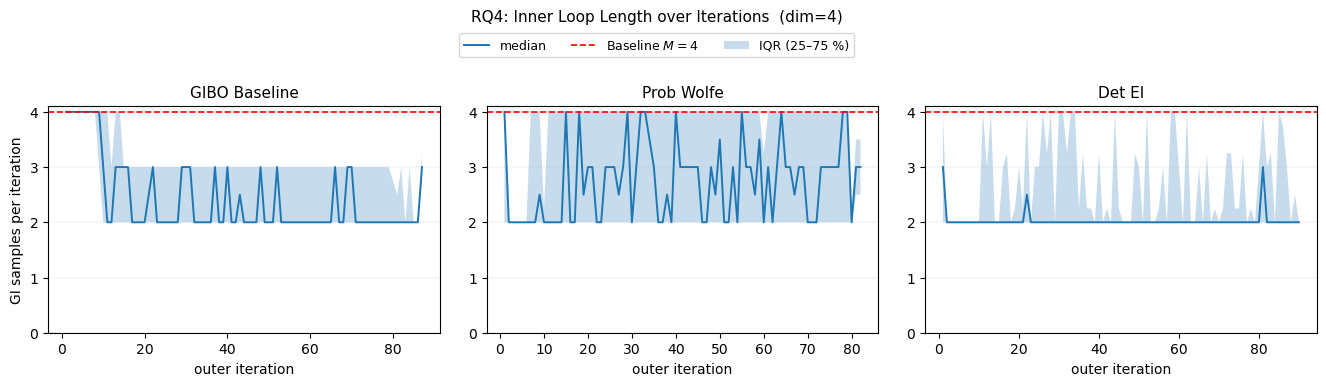

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim8.pdf


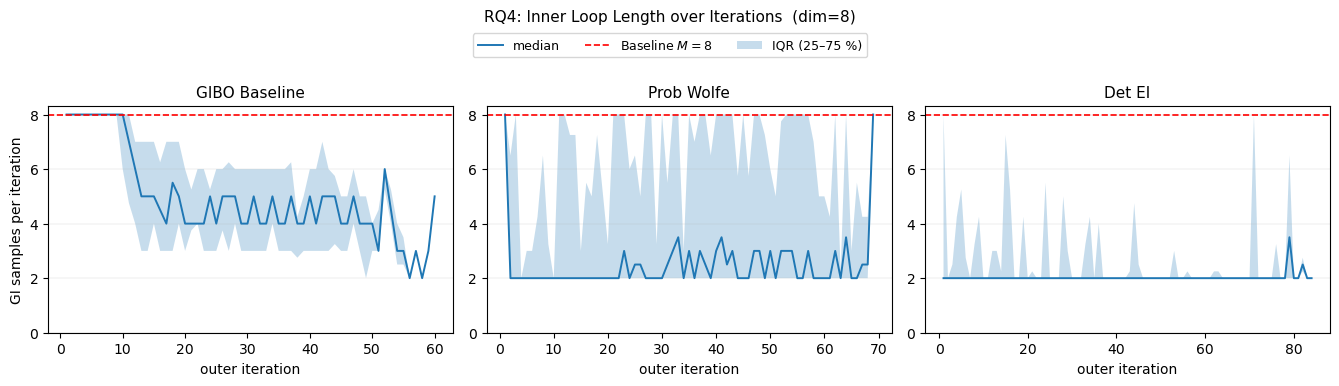

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim12.pdf


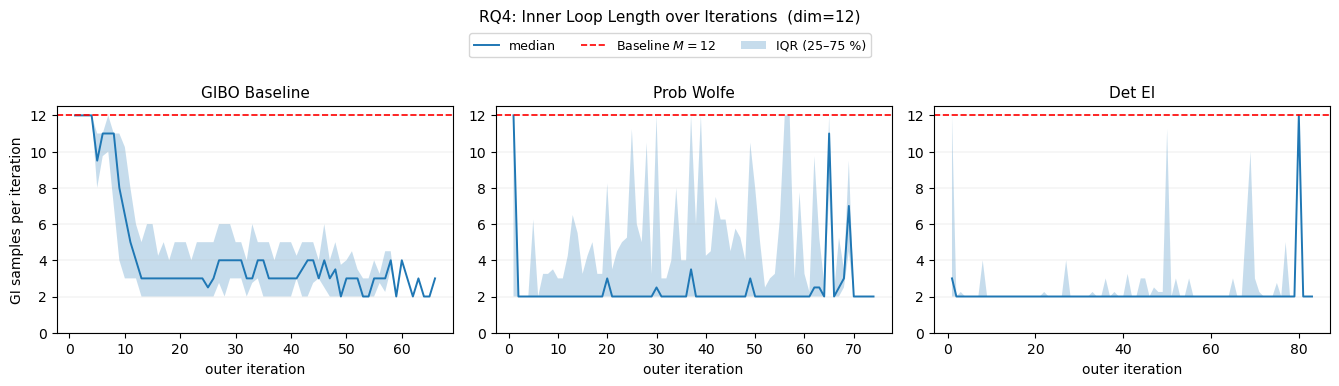

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim16.pdf


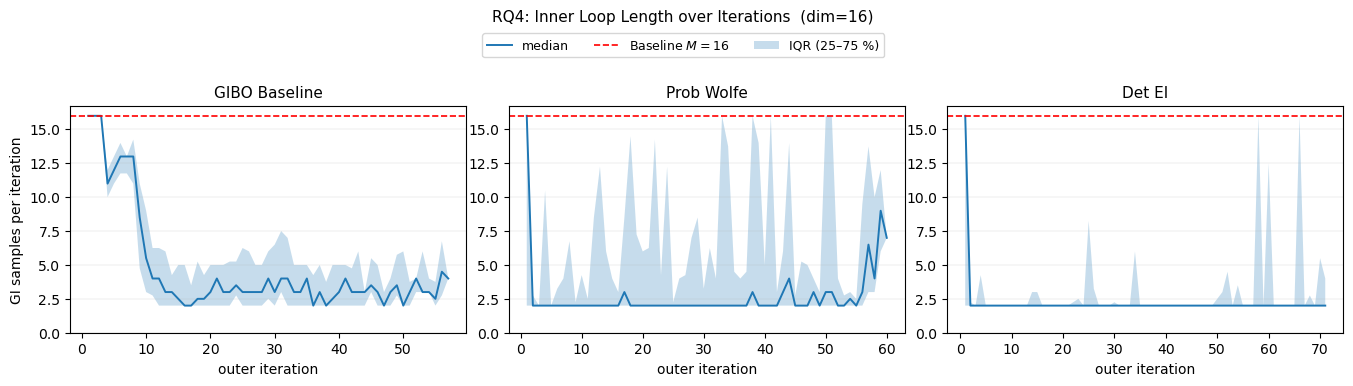

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim20.pdf


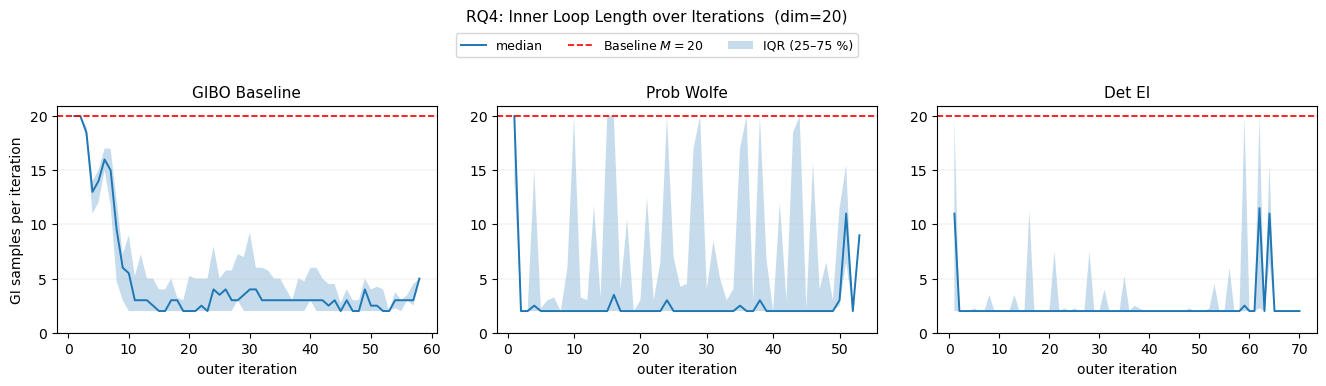

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim24.pdf


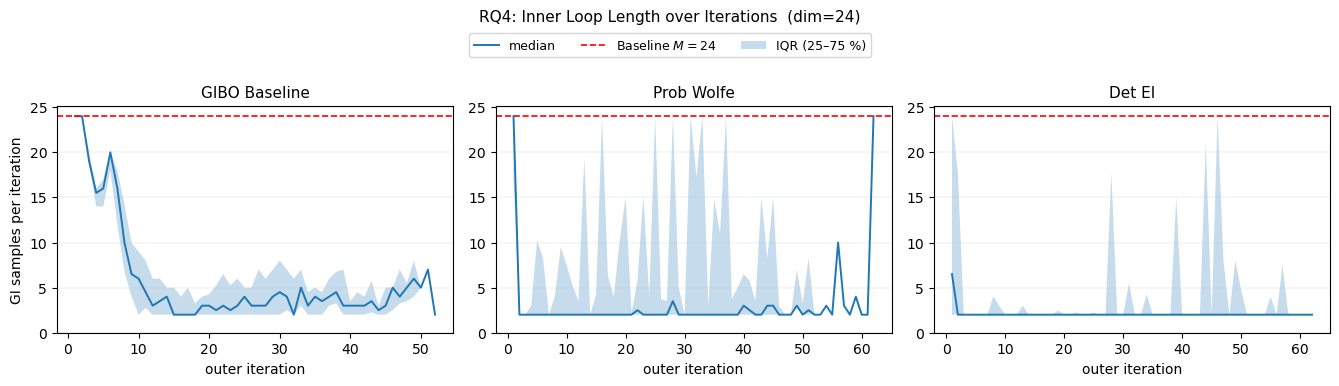

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim28.pdf


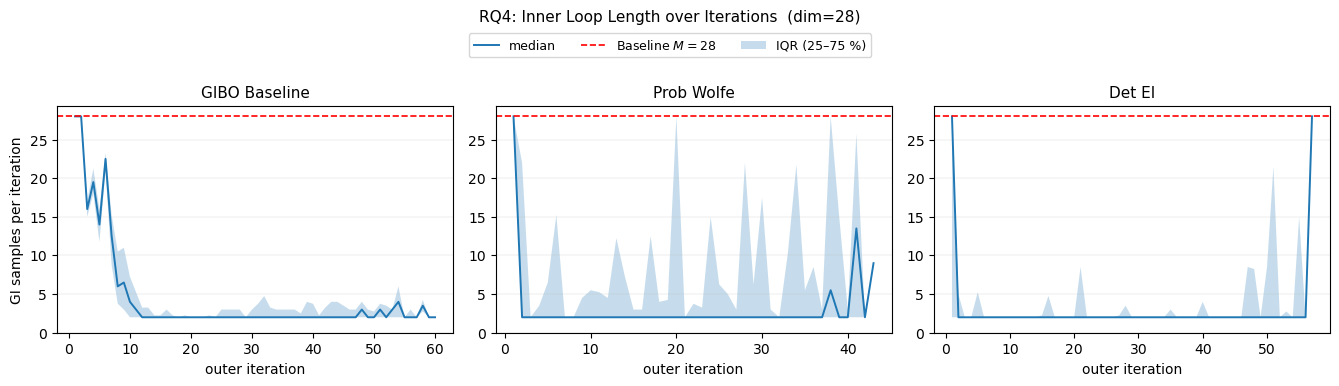

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim32.pdf


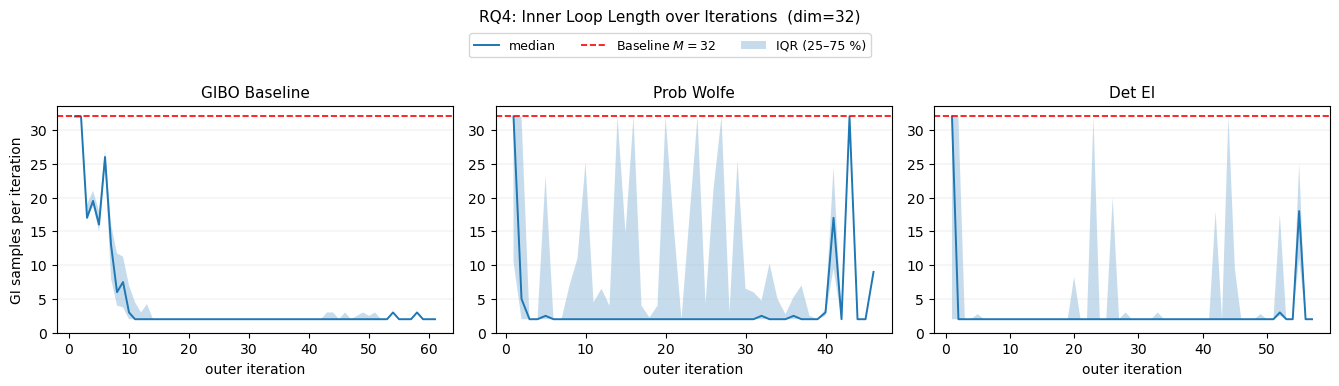

Saved: ../experiments/thesis_experiments/figures\inner_loop_over_iters_dim36.pdf


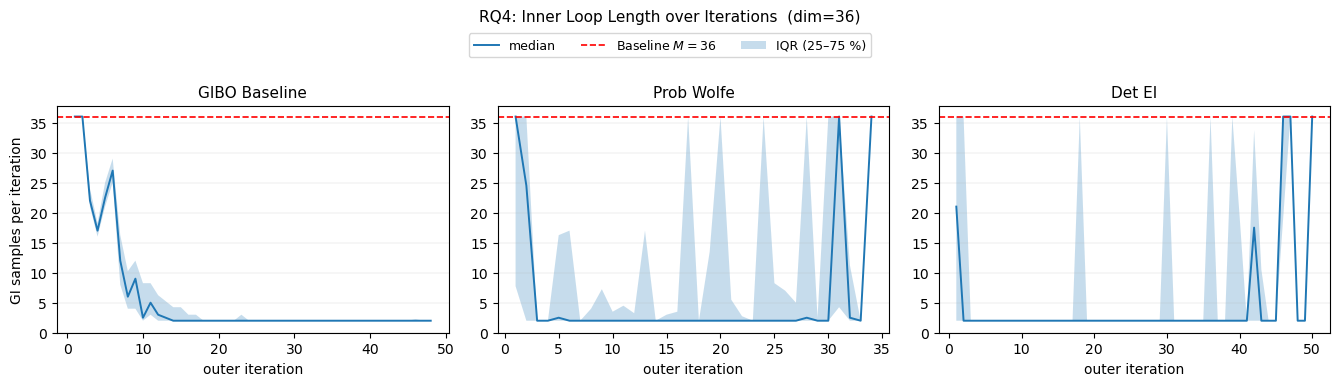

In [9]:
def plot_samples_over_iters(all_data, variants, available_dims, figures_dir=None):
    """Inner loop length over outer iterations --> one figure per dimension.
    Single shared legend per figure (no per-subplot duplication).
    """
    for dim in available_dims:
        n = len(variants)
        fig, axs = plt.subplots(1, n, sharey=False, figsize=(4.5 * n, 3.5))
        if n == 1:
            axs = [axs]

        for idx, (vname, vlabel) in enumerate(variants):
            ax   = axs[idx]
            runs = all_data[vname]['inner_loop_samples'].get(dim, [])
            if not runs:
                ax.set_title(f'{vlabel}\n(no data)')
                continue

            max_iters = max(len(r) for r in runs)
            padded = np.full((len(runs), max_iters), np.nan)
            for i, r in enumerate(runs):
                vals = [v for v in r if v is not None]
                padded[i, :len(vals)] = vals

            median = np.nanmedian(padded, axis=0)
            q25    = np.nanpercentile(padded, 25, axis=0)
            q75    = np.nanpercentile(padded, 75, axis=0)
            x      = np.arange(1, max_iters + 1)

            ax.plot(x, median, lw=1.4, label='median')
            ax.fill_between(x, q25, q75, alpha=0.25, label='IQR (25–75 %)')
            ax.axhline(dim, color='r', linestyle='--', lw=1.2,
                       label=f'Baseline $M={dim}$')

            ax.set_ylim(bottom=0)
            ax.yaxis.grid(True, linewidth=0.3, alpha=0.5)
            ax.set_title(vlabel, fontsize=11)
            ax.set_xlabel('outer iteration')

        axs[0].set_ylabel('GI samples per iteration')

        #One shared legend for the whole figure
        handles, labels = axs[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center',
                   bbox_to_anchor=(0.5, 1.04), ncol=3,
                   frameon=True, fontsize=9)

        plt.suptitle(f'RQ4: Inner Loop Length over Iterations  (dim={dim})',
                     fontsize=11, y=1.09)
        plt.tight_layout()
        if figures_dir:
            path = os.path.join(figures_dir, f'inner_loop_over_iters_dim{dim}.pdf')
            plt.savefig(path, bbox_inches='tight')
            print(f'Saved: {path}')
        plt.show()


plot_samples_over_iters(all_data, VARIANTS, available_dims, figures_dir=FIGURES_DIR)

## Block 8: RQ4 - p_Wolfe Trace (Variant A)

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim4.pdf


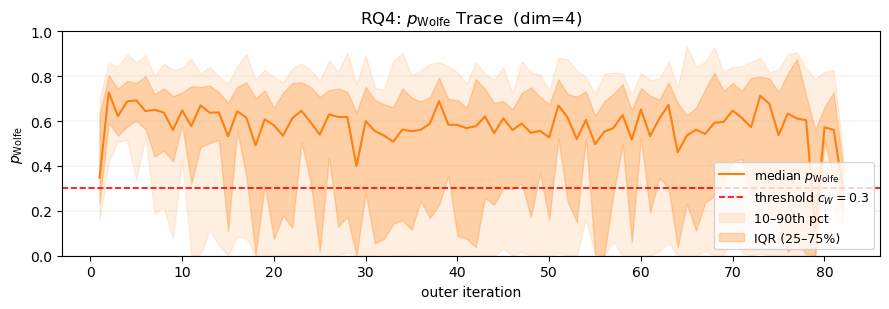

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim8.pdf


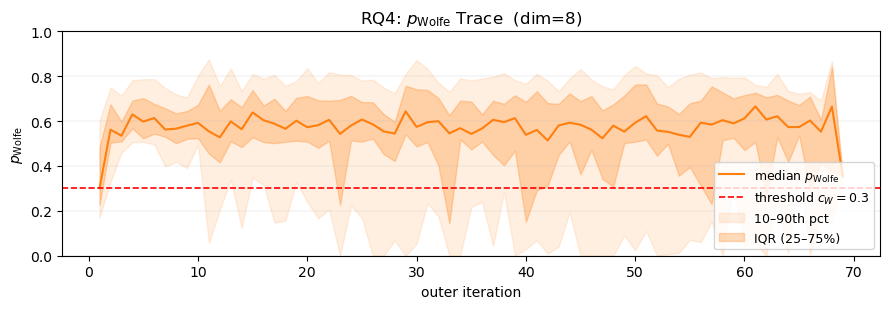

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim12.pdf


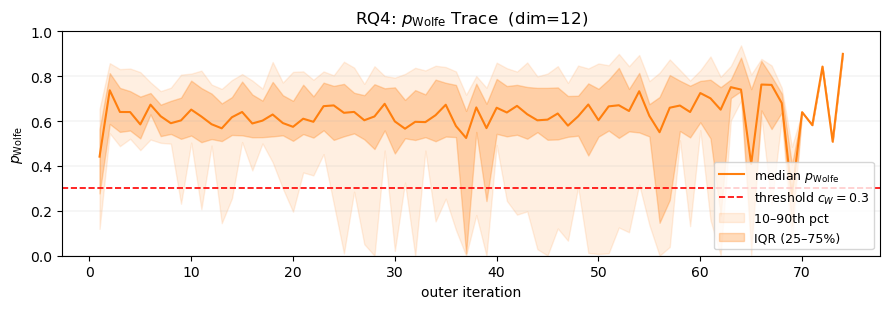

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim16.pdf


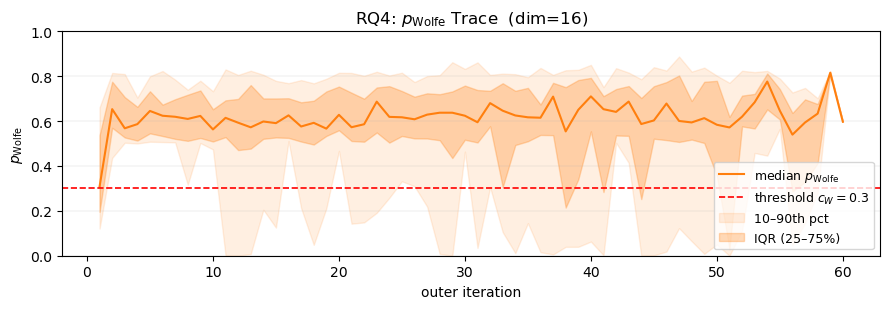

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim20.pdf


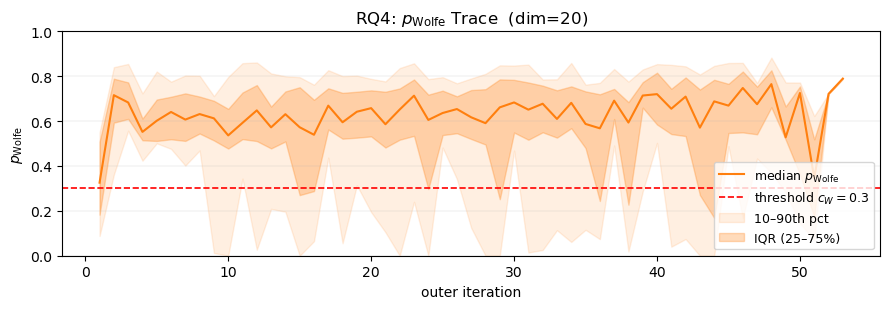

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim24.pdf


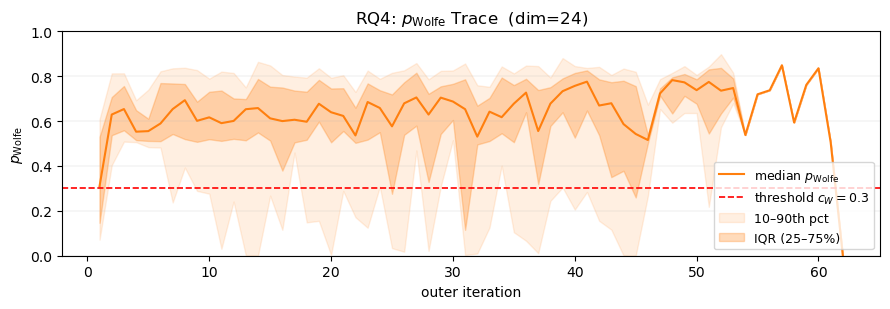

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim28.pdf


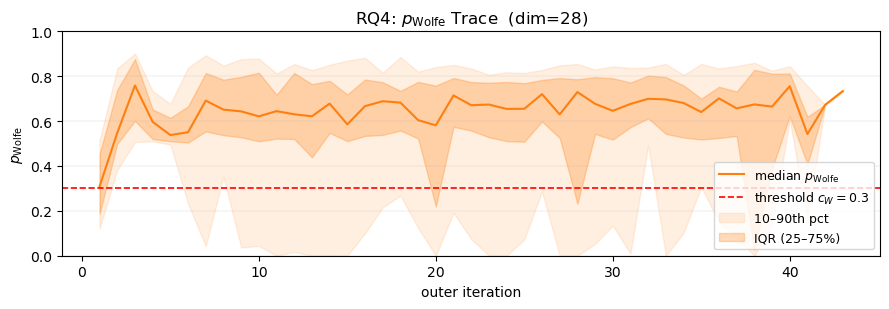

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim32.pdf


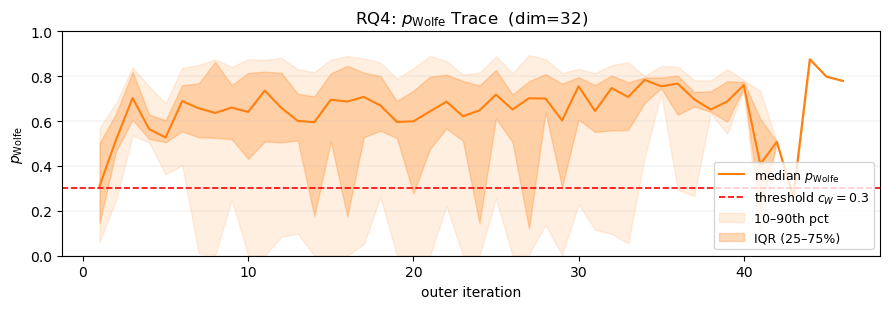

Saved: ../experiments/thesis_experiments/figures\p_wolfe_trace_dim36.pdf


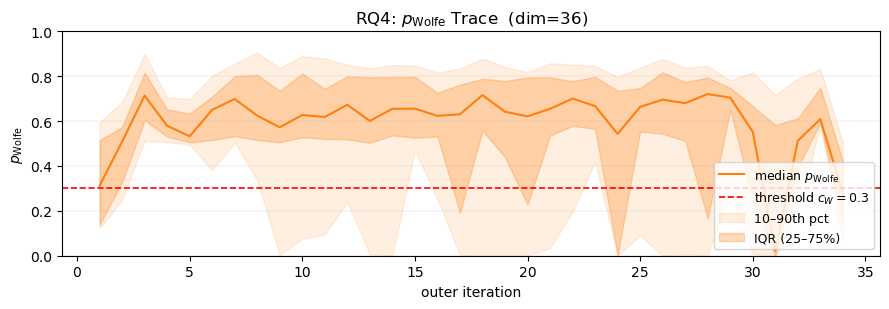

In [10]:
pw_vname = next((vn for vn, _ in VARIANTS if 'prob_wolfe' in vn), None)

if pw_vname is None:
    print('No prob_wolfe variant in VARIANTS — skipping.')
else:
    for dim in available_dims:
        runs = all_data[pw_vname]['p_wolfe_values'].get(dim, [])
        if not runs:
            print(f'No p_wolfe data for dim={dim}')
            continue

        max_iters = max(len(r) for r in runs)
        padded = np.full((len(runs), max_iters), np.nan)
        for i, r in enumerate(runs):
            vals = [v for v in r if v is not None]
            padded[i, :len(vals)] = vals

        median = np.nanmedian(padded, axis=0)
        q25    = np.nanpercentile(padded, 25, axis=0)
        q75    = np.nanpercentile(padded, 75, axis=0)
        q10    = np.nanpercentile(padded, 10, axis=0)
        q90    = np.nanpercentile(padded, 90, axis=0)
        x      = np.arange(1, max_iters + 1)

        fig, ax = plt.subplots(figsize=(9, 3.2))
        ax.fill_between(x, q10, q90, alpha=0.12, color='#ff7f0e', label='10–90th pct')
        ax.fill_between(x, q25, q75, alpha=0.28, color='#ff7f0e', label='IQR (25–75%)')
        ax.plot(x, median, lw=1.5, color='#ff7f0e', label='median $p_\\mathrm{Wolfe}$')
        ax.axhline(0.3, color='r', linestyle='--', lw=1.2,
                   label='threshold $c_W = 0.3$')

        ax.set_xlabel('outer iteration')
        ax.set_ylabel('$p_\\mathrm{Wolfe}$')
        ax.set_ylim([0, 1])
        ax.yaxis.grid(True, linewidth=0.3, alpha=0.5)
        ax.legend(fontsize=9, loc='lower right')
        ax.set_title(f'RQ4: $p_{{\\mathrm{{Wolfe}}}}$ Trace  (dim={dim})')
        plt.tight_layout()
        path = os.path.join(FIGURES_DIR, f'p_wolfe_trace_dim{dim}.pdf')
        plt.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')
        plt.show()

## Block 9: RQ4 - Armijo / Curvature Satisfaction Rate (Variant B)

Saved: ../experiments/thesis_experiments/figures\wolfe_satisfaction_det_ei.pdf


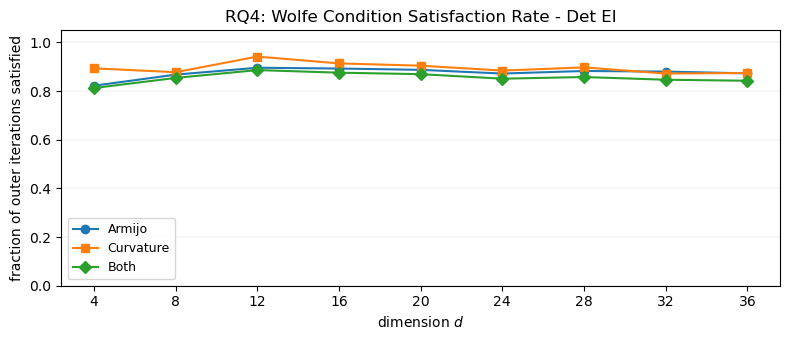


Det EI - Wolfe condition satisfaction rate per dimension  (mean over runs)
  Dim      Armijo     Curvature        Both
---------------------------------------------
    4      82.2%        89.4%      81.3%
    8      86.8%        87.8%      85.4%
   12      89.6%        94.2%      88.7%
   16      89.3%        91.4%      87.6%
   20      88.8%        90.5%      87.0%
   24      87.2%        88.5%      85.1%
   28      88.3%        89.8%      85.8%
   32      88.0%        87.2%      84.7%
   36      87.3%        87.5%      84.3%

Det EI - Wolfe satisfaction std across runs
  Dim     Armijo ±std    Curvature ±std       Both ±std
-------------------------------------------------------
    4   82.2% ± 0.028     89.4% ± 0.030   81.3% ± 0.027
    8   86.8% ± 0.041     87.8% ± 0.052   85.4% ± 0.046
   12   89.6% ± 0.037     94.2% ± 0.045   88.7% ± 0.040
   16   89.3% ± 0.036     91.4% ± 0.048   87.6% ± 0.043
   20   88.8% ± 0.038     90.5% ± 0.062   87.0% ± 0.049
   24   87.2% ± 0.039     88

In [11]:
ei_vname = next((vn for vn, _ in VARIANTS if 'det_ei' in vn), None)

if ei_vname is None:
    print('No det_ei variant in VARIANTS — skipping.')
else:
    arm_rates, cur_rates, both_rates = [], [], []
    for dim in available_dims:
        arm_vals, cur_vals, both_vals = [], [], []
        for arm_run, cur_run in zip(
            all_data[ei_vname]['armijo_ok'].get(dim, []),
            all_data[ei_vname]['curvature_ok'].get(dim, []),
        ):
            ac = [v for v in arm_run if v is not None]
            cc = [v for v in cur_run if v is not None]
            bc = [a and c for a, c in zip(ac, cc)]
            if ac:
                arm_vals.append(np.mean(ac))
                cur_vals.append(np.mean(cc))
                both_vals.append(np.mean(bc))
        arm_rates.append(np.mean(arm_vals)   if arm_vals  else np.nan)
        cur_rates.append(np.mean(cur_vals)   if cur_vals  else np.nan)
        both_rates.append(np.mean(both_vals) if both_vals else np.nan)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(available_dims, arm_rates,  'o-', lw=1.5, label='Armijo',    color='#1f77b4')
    ax.plot(available_dims, cur_rates,  's-', lw=1.5, label='Curvature', color='#ff7f0e')
    ax.plot(available_dims, both_rates, 'D-', lw=1.5, label='Both',      color='#2ca02c')

    ax.set_ylim([0, 1.05])
    ax.set_xticks(available_dims)
    ax.set_xlabel('dimension $d$')
    ax.set_ylabel('fraction of outer iterations satisfied')
    ax.yaxis.grid(True, linewidth=0.3, alpha=0.5)
    ax.legend(fontsize=9)
    ax.set_title('RQ4: Wolfe Condition Satisfaction Rate - Det EI')
    plt.tight_layout()
    path = os.path.join(FIGURES_DIR, 'wolfe_satisfaction_det_ei.pdf')
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()

    # Numeric summary table
    print('\nDet EI - Wolfe condition satisfaction rate per dimension  (mean over runs)')
    print(f"{'Dim':>5}  {'Armijo':>10}  {'Curvature':>12}  {'Both':>10}")
    print('-' * 45)
    for dim, ar, cr, br in zip(available_dims, arm_rates, cur_rates, both_rates):
        print(f'{dim:>5}  {ar:>9.1%}  {cr:>11.1%}  {br:>9.1%}')

    # Per-run std
    print('\nDet EI - Wolfe satisfaction std across runs')
    print(f"{'Dim':>5}  {'Armijo ±std':>14}  {'Curvature ±std':>16}  {'Both ±std':>14}")
    print('-' * 55)
    for dim in available_dims:
        av2, cv2, bv2 = [], [], []
        for arm_run, cur_run in zip(
            all_data[ei_vname]['armijo_ok'].get(dim, []),
            all_data[ei_vname]['curvature_ok'].get(dim, []),
        ):
            ac = [v for v in arm_run if v is not None]
            cc = [v for v in cur_run if v is not None]
            bc = [a and c for a, c in zip(ac, cc)]
            if ac:
                av2.append(np.mean(ac)); cv2.append(np.mean(cc)); bv2.append(np.mean(bc))
        if av2:
            print(f'{dim:>5}  '
                  f'{np.mean(av2):>6.1%} ± {np.std(av2):.3f}  '
                  f'{np.mean(cv2):>8.1%} ± {np.std(cv2):.3f}  '
                  f'{np.mean(bv2):>6.1%} ± {np.std(bv2):.3f}')